## Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter (od411d)

Der bisherige Datensatz **OD4117** (Fertilitätsrate nach Alter und Herkunft der Mutter) wurde am 15.05.2025 neu aufgeteilt in vier neue Datensätze:
 - [od411a: Fertilitätsrate nach Jahr](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a)
 - [od411b: Fertilitätsrate nach Jahr und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b)
 - [od411c: Fertilitätsrate nach Jahr und Alter der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c)
 - [od411d: Fertilitätsrate nach Jahr, Alter und Herkunft der Mutter](https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d)

 Wir schauen uns hier den ersten Datensatz an.
 
### Kurzbeschreibung
Fertilitätsraten nach Jahr, Alter und Herkunft der Mutter.

### Fertilitätsrate

Die altersspezifische Fertilitätsrate beschreibt das Verhältnis der Anzahl Geburten von Müttern eines Alters zu der Gesamtzahl Frauen der Bevölkerung im entsprechenden Alter. Sie wird oft in Promille angegeben und entspricht dann der durchschnittlichen Anzahl Geburten pro 1000 Frauen eines bestimmten Alters.

Datum: 15.05.2025


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_herkunftm_od411d

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d


### Importiere die notwendigen Packages

In [161]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [162]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [163]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [164]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [165]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [166]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
#pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [167]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

#### Paletten aus Zuericolors

In [168]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

Hier werden 4 Datenstätze auf einmal importiert, weil es sich hierbei früher um einen Datensatz genhandelt hat.

#### Import OD411A

In [169]:
package_name_a = "bev_fertilitaet_jahr_od411a"

df_od411a = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_a
    , dataset_name = "BEV411OD411A"    
    , datums_attr = ['StichtagDatJahr']
    )

df_od411a.head(3)

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a/download/BEV411OD411A.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_od411a 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_od411a 

data_source: web


,StichtagDatJahr,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM
0,1886-01-01,2455,NaN,NaN
1,1887-01-01,2482,NaN,NaN
2,1888-01-01,2498,NaN,NaN


#### Import OD411B

In [170]:
package_name_b = "bev_fertilitaet_jahr_herkunftm_od411b"

df_od411b = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_b
    , dataset_name = "BEV411OD411B"    
    , datums_attr = ['StichtagDatJahr']
    )


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b/download/BEV411OD411B.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_herkunftm_od411b 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_herkunftm_od411b 

data_source: web


#### Import OD411C

In [171]:
package_name_c = "bev_fertilitaet_jahr_alterm_od411c"

df_od411c = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_c
    , dataset_name = "BEV411OD411C"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c/download/BEV411OD411C.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_od411c 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_od411c 

data_source: web


#### Import OD411D

In [172]:
package_name_d = "bev_fertilitaet_jahr_alterm_herkunftm_od411d"

df_od411d = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name_d
    , dataset_name = "BEV411OD411D"    
    , datums_attr = ['StichtagDatJahr']
    )
#df_od411d.sort_values(['StichtagDatJahr', 'HerkunftMutterCd'], ascending=[False, True]).head(5).T

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d/download/BEV411OD411D.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_fertilitaet_jahr_alterm_herkunftm_od411d 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_fertilitaet_jahr_alterm_herkunftm_od411d 

data_source: web


#### Lege fest, welcher Datensatz dem `data2betested`zugewiesen wird:

In [173]:
data2betested = df_od411d

Berechne weitere Attribute falls notwendig

In [174]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr               datetime64[ns]
HerkunftMutterCd                       int64
HerkunftMutterLang                    object
AlterVMutterSpez1Cd_noDM               int64
AlterVMutterSpez1Lang_noDM            object
AnzGebuWir                             int64
Frauen15bis49_noDM                   float64
Fertilitaetsrate_noDM                float64
StichtagDatJahr_str                   object
Jahr                          datetime64[ns]
Jahr_end                      datetime64[ns]
Jahr_nbr                               int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [175]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")


Die Daten haben ein Minimumjahr von 1920 und ein Maximumjahr von 2025


In [176]:
#data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
#data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')
#print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

### Einfache Datentests

In [177]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 940 entries, 939 to 0
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   StichtagDatJahr             940 non-null    datetime64[ns]
 1   HerkunftMutterCd            940 non-null    int64         
 2   HerkunftMutterLang          940 non-null    object        
 3   AlterVMutterSpez1Cd_noDM    940 non-null    int64         
 4   AlterVMutterSpez1Lang_noDM  940 non-null    object        
 5   AnzGebuWir                  940 non-null    int64         
 6   Frauen15bis49_noDM          650 non-null    float64       
 7   Fertilitaetsrate_noDM       650 non-null    float64       
 8   StichtagDatJahr_str         940 non-null    object        
 9   Jahr                        940 non-null    datetime64[ns]
 10  Jahr_end                    940 non-null    datetime64[ns]
 11  Jahr_nbr                    940 non-null    int32         
dtyp

In [178]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 940 rows (observations) and 12 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [179]:
data2betested.describe()

,StichtagDatJahr,HerkunftMutterCd,AlterVMutterSpez1Cd_noDM,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr,Jahr_end,Jahr_nbr
count,940,940.000000,940.000000,940.000000,650.000000,650.000000,940,940,940.000000
mean,1978-05-05 05:06:22.978723392,1.500000,3.000000,437.219149,10163.783077,45.783692,1978-05-05 05:06:22.978723392,1979-05-04 11:14:02.553191488,1978.340426
min,1920-01-01 00:00:00,1.000000,1.000000,1.000000,1266.000000,0.600000,1920-01-01 00:00:00,1920-12-31 00:00:00,1920.000000
25%,1955-01-01 00:00:00,1.000000,2.000000,102.750000,5389.250000,15.200000,1955-01-01 00:00:00,1955-12-31 00:00:00,1955.000000
50%,1978-07-02 12:00:00,1.500000,3.000000,302.500000,9804.000000,43.500000,1978-07-02 12:00:00,1979-07-01 12:00:00,1978.500000
75%,2002-01-01 00:00:00,2.000000,4.000000,645.500000,12644.250000,74.175000,2002-01-01 00:00:00,2002-12-31 00:00:00,2002.000000
max,2025-01-01 00:00:00,2.000000,5.000000,1964.000000,34962.000000,127.600000,2025-01-01 00:00:00,2025-12-31 00:00:00,2025.000000
std,NaN,0.500266,1.414966,422.412127,5842.931119,32.148788,NaN,NaN,27.448685


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [180]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [181]:
data2betested.index.year.unique()

Index([1920, 1930, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946,
       1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
       1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
       1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [182]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,HerkunftMutterLang,AlterVMutterSpez1Lang_noDM,StichtagDatJahr_str,Jahr,Jahr_end
count,940,940,940,940,940
unique,2,5,94,NaN,NaN
top,Schweizerinnen,15- bis 24-Jährige,1920-01-01,NaN,NaN
freq,470,188,10,NaN,NaN
mean,NaN,NaN,NaN,1978-05-05 05:06:22.978723392,1979-05-04 11:14:02.553191488
min,NaN,NaN,NaN,1920-01-01 00:00:00,1920-12-31 00:00:00
25%,NaN,NaN,NaN,1955-01-01 00:00:00,1955-12-31 00:00:00
50%,NaN,NaN,NaN,1978-07-02 12:00:00,1979-07-01 12:00:00
75%,NaN,NaN,NaN,2002-01-01 00:00:00,2002-12-31 00:00:00
max,NaN,NaN,NaN,2025-01-01 00:00:00,2025-12-31 00:00:00


Beschreibe numerische Attribute

In [183]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftMutterCd,AlterVMutterSpez1Cd_noDM,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,Jahr_nbr
count,940,940,940,650,650,940
mean,2,3,437,"10,164",46,"1,978"
std,1,1,422,"5,843",32,27
min,1,1,1,"1,266",1,"1,920"
25%,1,2,103,"5,389",15,"1,955"
50%,2,3,302,"9,804",44,"1,978"
75%,2,4,646,"12,644",74,"2,002"
max,2,5,"1,964","34,962",128,"2,025"


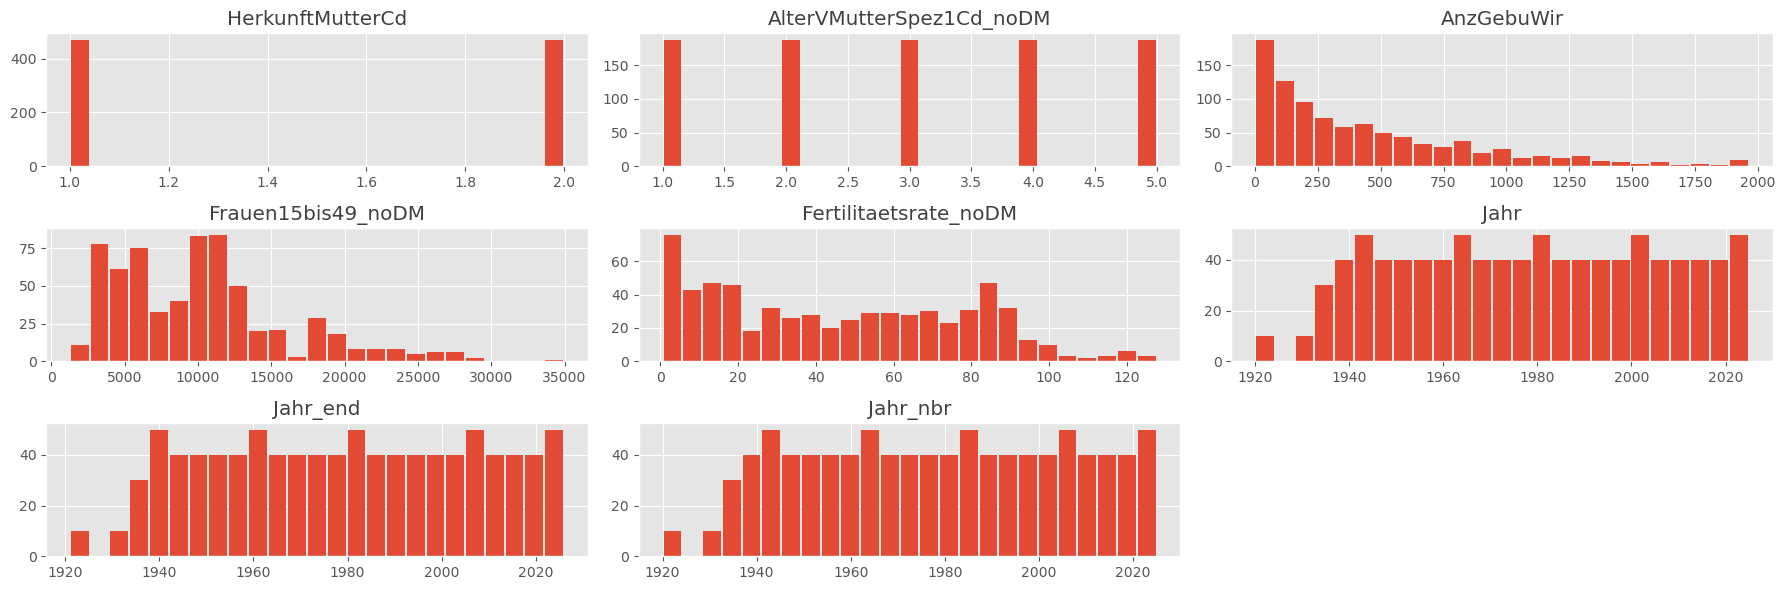

In [184]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [185]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated(keep=False)]
duplicate_rows

,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterSpez1Cd_noDM,AlterVMutterSpez1Lang_noDM,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,


### Nullwerte und Missings?

In [186]:
data2betested.isnull().sum()

HerkunftMutterCd                0
HerkunftMutterLang              0
AlterVMutterSpez1Cd_noDM        0
AlterVMutterSpez1Lang_noDM      0
AnzGebuWir                      0
Frauen15bis49_noDM            290
Fertilitaetsrate_noDM         290
StichtagDatJahr_str             0
Jahr                            0
Jahr_end                        0
Jahr_nbr                        0
dtype: int64

In den Metadaten beschrieben:
> "Bei den Geburtenzahlen der Jahr 1894, 1900 und 1910 nach Alter der Mutter waren bloss Mittelwerte über mehrere Jahre verfügbar (1894: Mittelwert der Geburten 1893 bis 1895; 1900: Mittelwert der Geburten 1899 bis 1902; 1910: Mittelwert der Geburten 1909 bis 1912). Quelle: Statistisches Jahrbuch der Stadt Zürich, Jahre 1912 und 1913. Die Geburtenzahlen dieser Jahre nach Alter der Mutter wurden auf ganze Zahlen gerunden; die Fertilitätsrate wurde jedoch noch vor dem Runden berechnet."

In [187]:
data2betested[data2betested['Fertilitaetsrate_noDM'].isna()].reset_index() \
    .groupby(['StichtagDatJahr']) \
    .agg(
        mean_AnzGebuWir = ('AnzGebuWir', 'mean'),
        count = ('AnzGebuWir', 'count')
    ).unstack()

                 StichtagDatJahr
mean_AnzGebuWir  1934-01-01         415.0
                 1935-01-01         422.2
                 1936-01-01         394.9
                 1937-01-01         373.6
                 1938-01-01         383.6
                 1939-01-01         380.8
                 1940-01-01         406.9
                 1942-01-01         527.3
                 1943-01-01         554.7
                 1944-01-01         576.9
                 1945-01-01         603.9
                 1946-01-01         593.7
                 1947-01-01         573.8
                 1948-01-01         542.3
                 1949-01-01         532.2
                 1951-01-01         528.2
                 1952-01-01         560.0
                 1953-01-01         569.8
                 1954-01-01         570.7
                 1955-01-01         589.9
                 1956-01-01         581.8
                 1957-01-01         594.1
                 1958-01-01         607.3
 

In [188]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

Anmerkung Alex: Scheinbar kann man die Daten nicht Gruppieren (es geht um die Fertilitätsrate). Der Schlüssel ist wohl die Spalte Thema. Je nach Thema gibt es verschiedene Untergruppierungen, die dazu kommen (Jahr, Herkunft, Alter).

In [189]:
    #.groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_jahr.reset_index().head(20)

,StichtagDatJahr,Jahr_nbr,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1920-01-01,1920,3048,72228.0,42.48
1,1930-01-01,1930,3436,86923.0,35.62
2,1934-01-01,1934,4150,0.0,NaN
3,1935-01-01,1935,4222,0.0,NaN
4,1936-01-01,1936,3949,0.0,NaN
5,1937-01-01,1937,3736,0.0,NaN
6,1938-01-01,1938,3836,0.0,NaN
7,1939-01-01,1939,3808,0.0,NaN
8,1940-01-01,1940,4069,0.0,NaN
9,1941-01-01,1941,4926,109470.0,42.80


In [190]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('HerkunftMutterCd', ascending=False) 
agg_herk.reset_index().head(10)

,HerkunftMutterCd,HerkunftMutterLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,2,Ausländerinnen,121004,1888035.0,54.063077
1,1,Schweizerinnen,289982,4718424.0,37.504308


In [191]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterVMutterSpez1Cd_noDM', 'AlterVMutterSpez1Lang_noDM']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('AlterVMutterSpez1Cd_noDM', ascending=True) 
agg_age.reset_index().head(11)

,AlterVMutterSpez1Cd_noDM,AlterVMutterSpez1Lang_noDM,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1,15- bis 24-Jährige,82989,1544162.0,36.213846
1,2,25- bis 29-Jährige,123787,1167991.0,66.199231
2,3,30- bis 34-Jährige,120444,1128807.0,72.038462
3,4,35- bis 39-Jährige,67985,1001508.0,47.643077
4,5,40- bis 49-Jährige,15781,1763991.0,6.823846


In [192]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterSpez1Cd_noDM',
       'AlterVMutterSpez1Lang_noDM', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Fertilitätsrate: Thema 4 Fertilität nach Jahr

In [193]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = agg_jahr
myAgg1.reset_index().head(3)


,StichtagDatJahr,Jahr_nbr,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1920-01-01,1920,3048,72228.0,42.48
1,1930-01-01,1930,3436,86923.0,35.62
2,1934-01-01,1934,4150,0.0,NaN


In [194]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'mean_Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Fertilitätsrate nach Jahr, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [195]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'sum_AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Geburten'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Anzahl Geburten nach Jahr, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [196]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDatJahr'
    ,y = 'sum_Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anzahl Frauen im gebährfähigen Alter'
    #,category = "ThemaLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Frauen im gebährfähigen Alter nach Jahr, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 3 Fertilität nach Jahr und Herkunft der Mutter

In [197]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr', 'HerkunftMutterCd', 'HerkunftMutterLang']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,HerkunftMutterCd,HerkunftMutterLang,sum_AnzGebuWir,sum_Frauen15bis49_noDM,mean_Fertilitaetsrate_noDM
0,1920-01-01,1920,1,Schweizerinnen,2505,53575.0,51.86
1,1920-01-01,1920,2,Ausländerinnen,543,18653.0,33.10
2,1930-01-01,1930,1,Schweizerinnen,3020,69956.0,45.86


In [198]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'mean_Fertilitaetsrate_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,custom_palette=[zuericolors_qual12br[0], zuericolors_qual12br[4]]
    ,myTitle="Fertilitätsrate nach Jahr und Herkunft, seit "+data_min_date
)
grafik4

alt.LayerChart(...)

In [199]:
grafik5 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'sum_AnzGebuWir'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Geburten'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,custom_palette=[zuericolors_qual12br[0], zuericolors_qual12br[4]]
    ,myTitle="Anzahl Geburten nach Jahr und Herkunft der Mutter, seit "+data_min_date
)
grafik5

alt.LayerChart(...)

In [200]:
grafik6 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftMutterCd', ascending=True)
    ,x = 'StichtagDatJahr'
    ,y = 'sum_Frauen15bis49_noDM'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Frauen im gebährfähigen Alter'
    ,category = "HerkunftMutterLang"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,custom_palette=[zuericolors_qual12br[0], zuericolors_qual12br[4]]
    ,myTitle="Anz. Frauen im gebährfähigen Alter nach Jahr und Herkunft, seit "+data_min_date
)
grafik6

alt.LayerChart(...)

#### Entwicklung Fertilitätsrate: Thema 2 Fertilität nach Jahr und Alter der Mutter

In [201]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'Jahr_nbr', 'AlterVMutterSpez1Cd_noDM', 'AlterVMutterSpez1Lang_noDM']) \
    .agg(
            sum_AnzGebuWir=('AnzGebuWir', 'sum'), 
            sum_Frauen15bis49_noDM=('Frauen15bis49_noDM', 'sum'), 
            mean_Fertilitaetsrate_noDM=('Fertilitaetsrate_noDM', 'mean')) \
    .sort_values('Jahr_nbr', ascending=True) 

In [202]:
grafik7 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index()
    ,x = 'StichtagDatJahr:T'
    ,y = 'mean_Fertilitaetsrate_noDM:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Fertilitätsrate'
    ,category = "AlterVMutterSpez1Lang_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,custom_palette=zuericolors_qual12
    ,myTitle="Fertilität nach Jahr und Alter der Mutter, seit "+data_min_date
)
grafik7

alt.LayerChart(...)

In [203]:
data2betested.columns

Index(['HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterSpez1Cd_noDM',
       'AlterVMutterSpez1Lang_noDM', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Entwicklung Fertilitätsrate: Thema 1 Fertilität nach Jahr, Alter und Herkunft der Mutter

#### Faced Grids

In [204]:
data2betested.columns

Index(['HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterSpez1Cd_noDM',
       'AlterVMutterSpez1Lang_noDM', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [205]:
#data2betested[['ThemaCd','ThemaLang']].reset_index(drop=True).drop_duplicates()

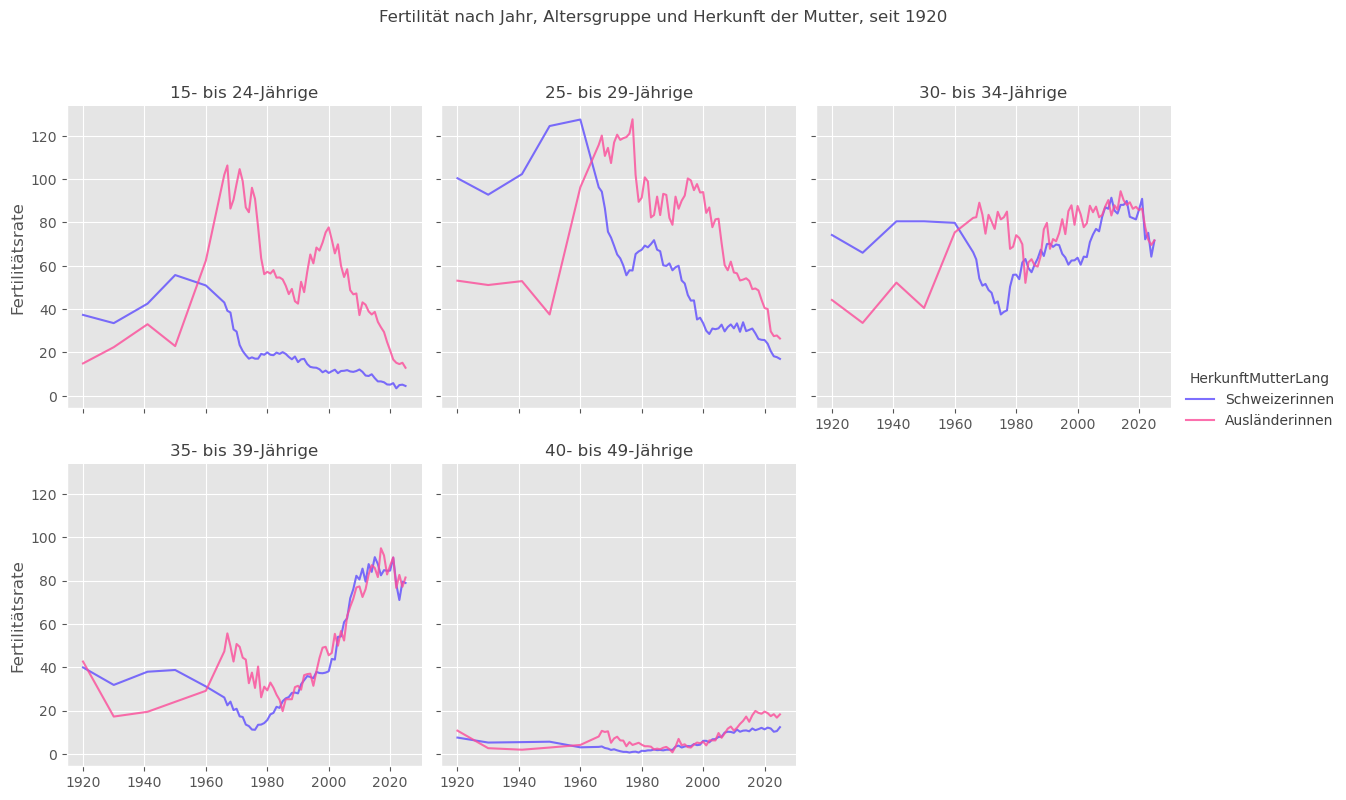

In [206]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('AlterVMutterSpez1Cd_noDM')
    ,col = "AlterVMutterSpez1Lang_noDM"
    ,hue = "HerkunftMutterLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Fertilitaetsrate_noDM"
    ,ylabel= "Fertilitätsrate"
    ,warning_status ="ignore"
    ,height = 3
    ,palette = [zuericolors_qual12br[0], zuericolors_qual12br[4]]
    ,myTitle="Fertilität nach Jahr, Altersgruppe und Herkunft der Mutter, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [207]:
data2betested.columns

Index(['HerkunftMutterCd', 'HerkunftMutterLang', 'AlterVMutterSpez1Cd_noDM',
       'AlterVMutterSpez1Lang_noDM', 'AnzGebuWir', 'Frauen15bis49_noDM', 'Fertilitaetsrate_noDM',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [208]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterVMutterSpez1Lang_noDM'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12 + zuericolors_qual12br + zuericolors_qual12da + zuericolors_div9val + zuericolors_div9ntr + zuericolors_gender3 + zuericolors_gender6origin + zuericolors_gender5wedding + zuericolors_seq9blu + zuericolors_seq9red + zuericolors_seq9grn + zuericolors_seq9brn

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '15- bis 24-Jährige': '#3431DE', '30- bis 34-Jährige': '#0A8DF6', '25- bis 29-Jährige': '#23C3F1', '40- bis 49-Jährige': '#7B4FB7', '35- bis 39-Jährige': '#DB247D'}


##### Aufschlüssellung im aktuellsten Jahr

In [209]:
data2betested.loc[data_min_date:data_max_date]

,HerkunftMutterCd,HerkunftMutterLang,AlterVMutterSpez1Cd_noDM,AlterVMutterSpez1Lang_noDM,AnzGebuWir,Frauen15bis49_noDM,Fertilitaetsrate_noDM,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,
1920-01-01,1,Schweizerinnen,1,15- bis 24-Jährige,630,16899.0,37.3,1920-01-01,1920-01-01,1920-12-31,1920
1920-01-01,2,Ausländerinnen,3,30- bis 34-Jährige,130,2939.0,44.2,1920-01-01,1920-01-01,1920-12-31,1920
1920-01-01,1,Schweizerinnen,2,25- bis 29-Jährige,929,9257.0,100.4,1920-01-01,1920-01-01,1920-12-31,1920
1920-01-01,2,Ausländerinnen,2,25- bis 29-Jährige,175,3296.0,53.1,1920-01-01,1920-01-01,1920-12-31,1920
1920-01-01,1,Schweizerinnen,3,30- bis 34-Jährige,572,7707.0,74.2,1920-01-01,1920-01-01,1920-12-31,1920
...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2,Ausländerinnen,3,30- bis 34-Jährige,820,11438.0,71.7,2025-01-01,2025-01-01,2025-12-31,2025
2025-01-01,1,Schweizerinnen,4,35- bis 39-Jährige,898,11376.0,78.9,2025-01-01,2025-01-01,2025-12-31,2025
2025-01-01,2,Ausländerinnen,4,35- bis 39-Jährige,832,10219.0,81.4,2025-01-01,2025-01-01,2025-12-31,2025


In [210]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_max_date].reset_index()
    ,levels=['HerkunftMutterLang','AlterVMutterSpez1Lang_noDM']
    ,values="Fertilitaetsrate_noDM"
    ,color="AlterVMutterSpez1Lang_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=800               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, "+str(data2betested.index.max().year)
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001E9CE5BDC90>, 'HerkunftMutterLang', 'AlterVMutterSpez1Lang_noDM']
Typ von path: <class 'list'>


In [211]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_min_date:data_max_date].reset_index()
    ,levels=['Jahr','AlterVMutterSpez1Lang_noDM','HerkunftMutterLang']
    ,values="Fertilitaetsrate_noDM"
    ,color="AlterVMutterSpez1Lang_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, seit "+str(data2betested.index.min().year)
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000001E9CE82B650>, 'Jahr', 'AlterVMutterSpez1Lang_noDM', 'HerkunftMutterLang']
Typ von path: <class 'list'>


In [212]:
myTM3 = data2betested.loc[data_min_date:data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'HerkunftMutterLang']) \
    .agg(meanFertRat=('Fertilitaetsrate_noDM', 'mean'), sum_AnzGebuWir=('AnzGebuWir', 'mean')) \
    .sort_values('meanFertRat', ascending=False) 
myTM3.reset_index().head(2)

,StichtagDatJahr,HerkunftMutterLang,meanFertRat,sum_AnzGebuWir
0,1967-01-01,Ausländerinnen,75.0,355.2
1,1971-01-01,Ausländerinnen,72.3,331.4


In [213]:
treeMap3 = mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()    
    ,levels=['StichtagDatJahr','HerkunftMutterLang']
    ,values="meanFertRat"
    ,color="HerkunftMutterLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Fertilitätsrate, seit "+str(data2betested.index.min().year)
)
treeMap3


path: [<plotly.express._special_inputs.Constant object at 0x000001E9CB58D390>, 'StichtagDatJahr', 'HerkunftMutterLang']
Typ von path: <class 'list'>


In [214]:
treeMap4 = mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()    
    ,levels=['StichtagDatJahr','HerkunftMutterLang']
    ,values="sum_AnzGebuWir"
    ,color="HerkunftMutterLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Anzahl Geburten, seit "+str(data2betested.index.min().year)
)
treeMap4

path: [<plotly.express._special_inputs.Constant object at 0x000001E9CCEE17D0>, 'StichtagDatJahr', 'HerkunftMutterLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1565&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7BCEAF2600%2D5498%2D413B%2D88AA%2DBEE20C2F4F2F%7D%23InplviewHashceaf2600%2D5498%2D413b%2D88aa%2Dbee20c2f4f2f%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------